<a href="https://colab.research.google.com/github/Kunalthakur01/rock-vs-mine/blob/main/Rock_vs_mine_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
sonar_df = pd.read_csv("Copy of sonar data.csv", header=None)

In [3]:
sonar_df.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
92,0.0260,0.0192,0.0254,0.0061,0.0352,0.0701,0.1263,0.1080,0.1523,0.1630,...,0.0118,0.0120,0.0051,0.0070,0.0015,0.0035,0.0008,0.0044,0.0077,R
177,0.0201,0.0165,0.0344,0.0330,0.0397,0.0443,0.0684,0.0903,0.1739,0.2571,...,0.0054,0.0057,0.0137,0.0109,0.0035,0.0056,0.0105,0.0082,0.0036,M
68,0.0195,0.0142,0.0181,0.0406,0.0391,0.0249,0.0892,0.0973,0.0840,0.1191,...,0.0028,0.0067,0.0120,0.0012,0.0022,0.0058,0.0042,0.0067,0.0012,R
47,0.0373,0.0281,0.0232,0.0225,0.0179,0.0733,0.0841,0.1031,0.0993,0.0802,...,0.0008,0.0045,0.0024,0.0006,0.0073,0.0096,0.0054,0.0085,0.0060,R
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


In [4]:
#number of row and columns
sonar_df.shape

(208, 61)

In [5]:
sonar_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


M----> mine
R----> Rock

In [6]:
sonar_df[60].value_counts()

,count
60,
M,111
R,97


In [7]:
#seprating data and labels
X=sonar_df.drop(columns=60, axis=1)
y=sonar_df[60]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC())
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=3,
            metric="manhattan"
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(f"{name}:")
    print(f"  CV Accuracy: {scores.mean():.4f}")
    print(f"  Std: {scores.std():.4f}")
    print()

Logistic Regression:
  CV Accuracy: 0.7836
  Std: 0.0153

SVM:
  CV Accuracy: 0.8413
  Std: 0.0423

KNN:
  CV Accuracy: 0.8368
  Std: 0.0304

Random Forest:
  CV Accuracy: 0.8366
  Std: 0.0509

Decision Tree:
  CV Accuracy: 0.7116
  Std: 0.0333



In [10]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

param_grid = {
    "svm__C": [0.01, 0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "svm__kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X, y)

print("Best Parameters:")
print(svm_grid.best_params_)

print("\nBest CV Accuracy:")
print(svm_grid.best_score_)

Best Parameters:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

Best CV Accuracy:
0.8799070847851336


In [11]:


# Get best model
best_svm = svm_grid.best_estimator_

# Train on training data only
best_svm.fit(X_train, y_train)

# Predict test data
y_pred = best_svm.predict(X_test)

# Test accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.8809523809523809

Classification Report:
              precision    recall  f1-score   support

           M       0.84      0.95      0.89        22
           R       0.94      0.80      0.86        20

    accuracy                           0.88        42
   macro avg       0.89      0.88      0.88        42
weighted avg       0.89      0.88      0.88        42



[[21  1]
 [ 4 16]]


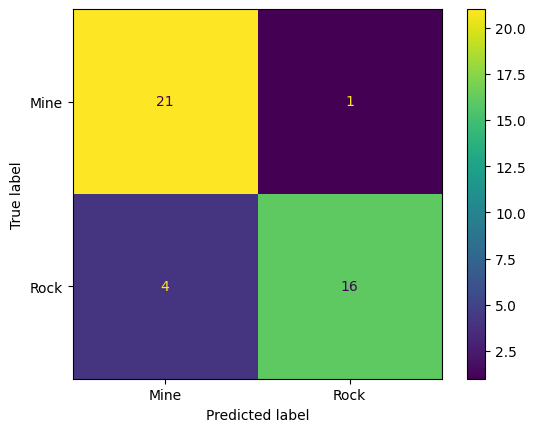

In [12]:


cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Mine", "Rock"]
).plot()

In [13]:
input_data = (0.1313,0.2339,0.3059,0.4264,0.4010,0.1791,0.1853,0.0055,0.1929,0.2231,0.2907,0.2259,0.3136,0.3302,0.3660,0.3956,0.4386,0.4670,0.5255,0.3735,0.2243,0.1973,0.4337,0.6532,0.5070,0.2796,0.4163,0.5950,0.5242,0.4178,0.3714,0.2375,0.0863,0.1437,0.2896,0.4577,0.3725,0.3372,0.3803,0.4181,0.3603,0.2711,0.1653,0.1951,0.2811,0.2246,0.1921,0.1500,0.0665,0.0193,0.0156,0.0362,0.0210,0.0154,0.0180,0.0013,0.0106,0.0127,0.0178,0.0231)
#changing the input_data to numpy array
input_data_as_numpy_array =np.asarray(input_data)

#reshape the np arrayas we are prediciting for one  instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = best_svm.predict(input_data_reshaped)
print(prediction)

if(prediction[0]=='R'):
  print("the object is a rock")
else:
  print("the object is a mine")

['M']
the object is a mine


# Conclusion

Several classification algorithms were evaluated using stratified
5-fold cross-validation.

SVM achieved the highest initial cross-validation accuracy.

After hyperparameter tuning, the best configuration was:

- Kernel: RBF
- C: 10
- Gamma: scale

The tuned SVM achieved:

- 5-Fold Cross-Validation Accuracy: 87.99%
- Held-Out Test Accuracy: 88.10%

The final model was evaluated using accuracy, precision, recall,
F1-score, and a confusion matrix.

The trained SVM pipeline was also used to predict a new sonar sample.